#### 1- Project Introduction
 
This project analyzes the Spotify Top 50 tracks from 2020. The goal is to understand which audio features are common among popular songs, identify patterns across genres, detect unusual tracks, and summarize music trends based on the dataset.

In this section, I load the Spotify Top 50 dataset and perform an initial inspection to understand its structure, data types, missing values, duplicates, and basic statistical properties.

#### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


#### 2- Dataset Loading

In [2]:
df = pd.read_csv('D:/gitrepos/spotify-top50-2020-analysis/data/raw/spotifytoptracks.csv')
df.reset_index(drop=True, inplace= True)
df

,Unnamed: 0,artist,album,track_name,track_id,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,genre
0,0,The Weeknd,After Hours,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0.730,0.514,1,-5.934,0.00146,0.0598,0.000095,0.0897,0.3340,171.005,200040,R&B/Soul
1,1,Tones And I,Dance Monkey,Dance Monkey,1rgnBhdG2JDFTbYkYRZAku,0.593,0.825,6,-6.401,0.68800,0.0988,0.000161,0.1700,0.5400,98.078,209755,Alternative/Indie
2,2,Roddy Ricch,Please Excuse Me For Being Antisocial,The Box,0nbXyq5TXYPCO7pr3N8S4I,0.586,0.896,10,-6.687,0.10400,0.0559,0.000000,0.7900,0.6420,116.971,196653,Hip-Hop/Rap
3,3,SAINt JHN,Roses (Imanbek Remix),Roses - Imanbek Remix,2Wo6QQD1KMDWeFkkjLqwx5,0.721,0.785,8,-5.457,0.01490,0.0506,0.004320,0.2850,0.8940,121.962,176219,Dance/Electronic
4,4,Dua Lipa,Future Nostalgia,Don't Start Now,3PfIrDoz19wz7qK7tYeu62,0.793,0.793,11,-4.521,0.01230,0.0830,0.000000,0.0951,0.6790,123.950,183290,Nu-disco
5,5,DaBaby,BLAME IT ON BABY,ROCKSTAR (feat. Roddy Ricch),7ytR5pFWmSjzHJIeQkgog4,0.690,0.746,11,-7.956,0.24700,0.1640,0.000000,0.1010,0.4970,89.977,181733,Hip-Hop/Rap
6,6,Harry Styles,Fine Line,Watermelon Sugar,6UelLqGlWMcVH1E5c4H7lY,0.816,0.548,0,-4.209,0.12200,0.0465,0.000000,0.3350,0.5570,95.390,174000,Pop
7,7,Powfu,death bed (coffee for your head),death bed (coffee for your head),7eJMfftS33KTjuF7lTsMCx,0.431,0.726,8,-8.765,0.73100,0.1350,0.000000,0.6960,0.3480,144.026,173333,Hip-Hop/Rap
8,8,Trevor Daniel,Nicotine,Falling,2rRJrJEo19S2J82BDsQ3F7,0.430,0.784,10,-8.756,0.12300,0.0364,0.000000,0.0887,0.2360,127.087,159382,R&B/Hip-Hop alternative
9,9,Lewis Capaldi,Divinely Uninspired To A Hellish Extent,Someone You Loved,7qEHsqek33rTcFNT9PFqLf,0.405,0.501,1,-5.679,0.75100,0.0319,0.000000,0.1050,0.4460,109.891,182161,Alternative/Indie


#### 3- Dataset Understanding 

In [3]:
print(df.info()) 

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        50 non-null     int64  
 1   artist            50 non-null     str    
 2   album             50 non-null     str    
 3   track_name        50 non-null     str    
 4   track_id          50 non-null     str    
 5   energy            50 non-null     float64
 6   danceability      50 non-null     float64
 7   key               50 non-null     int64  
 8   loudness          50 non-null     float64
 9   acousticness      50 non-null     float64
 10  speechiness       50 non-null     float64
 11  instrumentalness  50 non-null     float64
 12  liveness          50 non-null     float64
 13  valence           50 non-null     float64
 14  tempo             50 non-null     float64
 15  duration_ms       50 non-null     int64  
 16  genre             50 non-null     str    
dtypes: float64

#### 4- Data Cleaning

In [4]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Remove extra spaces from text columns
df["genre"] = df["genre"].str.strip()
df["artist"] = df["artist"].str.strip()
df["album"] = df["album"].str.strip()
df["track_name"] = df["track_name"].str.strip()

# Check and remove missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

df.dropna(inplace=True)

# Check and remove duplicate rows
duplicated_rows = df.duplicated().sum()
print("Duplicated rows:", duplicated_rows)

if duplicated_rows > 0:
    df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

print("Cleaned dataset shape:", df.shape)
print(df.head())

Missing values before cleaning:
artist              0
album               0
track_name          0
track_id            0
energy              0
danceability        0
key                 0
loudness            0
acousticness        0
speechiness         0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
genre               0
dtype: int64
Duplicated rows: 0
Cleaned dataset shape: (50, 16)
        artist                                  album             track_name  \
0   The Weeknd                            After Hours        Blinding Lights   
1  Tones And I                           Dance Monkey           Dance Monkey   
2  Roddy Ricch  Please Excuse Me For Being Antisocial                The Box   
3    SAINt JHN                  Roses (Imanbek Remix)  Roses - Imanbek Remix   
4     Dua Lipa                       Future Nostalgia        Don't Start Now   

                 track_id  energy  danceability  key  loudness  acousti

In [5]:
# Check basic statistic
df.describe()

,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.609300,0.716720,5.720000,-6.225900,0.256206,0.124158,0.015962,0.196552,0.555710,119.690460,199955.360000
std,0.154348,0.124975,3.709007,2.349744,0.265250,0.116836,0.094312,0.176610,0.216386,25.414778,33996.122488
min,0.225000,0.351000,0.000000,-14.454000,0.001460,0.029000,0.000000,0.057400,0.060500,75.801000,140526.000000
25%,0.494000,0.672500,2.000000,-7.552500,0.052800,0.048325,0.000000,0.093950,0.434000,99.557250,175845.500000
50%,0.597000,0.746000,6.500000,-5.991500,0.188500,0.070050,0.000000,0.111000,0.560000,116.969000,197853.500000
75%,0.729750,0.794500,8.750000,-4.285500,0.298750,0.155500,0.000020,0.271250,0.726250,132.317000,215064.000000
max,0.855000,0.935000,11.000000,-3.280000,0.934000,0.487000,0.657000,0.792000,0.925000,180.067000,312820.000000


#### 5- Exploratory Data Analysis

##### Genre distribution: 

Which genres appear most frequently in the Top 50?

In [6]:
# Count number of songs in each genre
genre_counts = df["genre"].value_counts()
print(genre_counts)

genre
Pop                                   14
Hip-Hop/Rap                           13
Dance/Electronic                       5
Alternative/Indie                      4
R&B/Soul                               2
Electro-pop                            2
Nu-disco                               1
R&B/Hip-Hop alternative                1
Pop/Soft Rock                          1
Pop rap                                1
Hip-Hop/Trap                           1
Dance-pop/Disco                        1
Disco-pop                              1
Dreampop/Hip-Hop/R&B                   1
Alternative/reggaeton/experimental     1
Chamber pop                            1
Name: count, dtype: int64


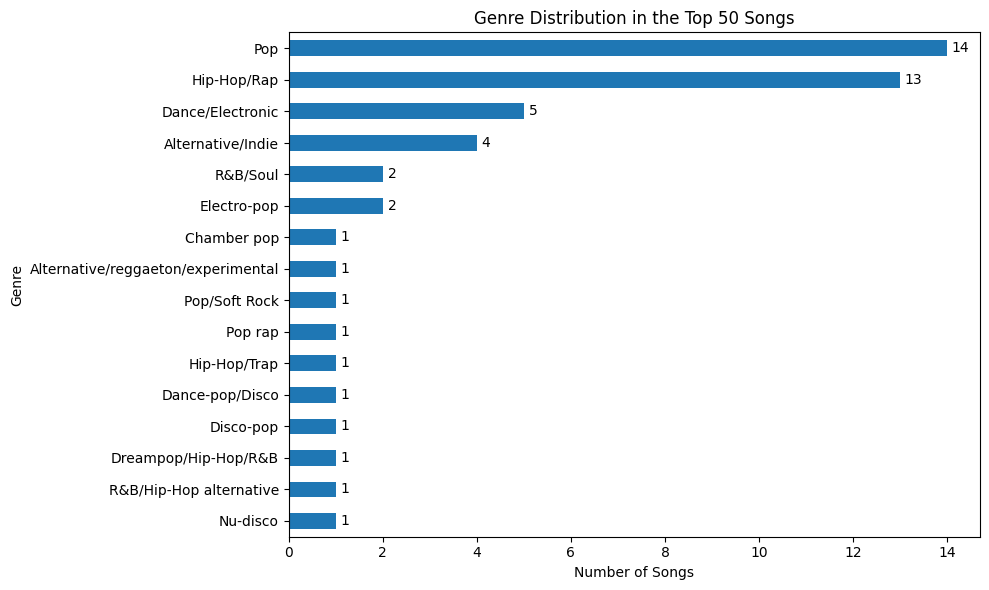

In [7]:
plt.figure(figsize=(10, 6))
ax = genre_counts.sort_values().plot(kind="barh")
plt.title("Genre Distribution in the Top 50 Songs")
plt.xlabel("Number of Songs")
plt.ylabel("Genre")
plt.tight_layout()
# Add value labels
for i, value in enumerate(genre_counts.sort_values()):
    ax.text(value + 0.1, i, str(value), va="center")
plt.show()

The genre distribution shows that Pop is the most frequent genre in the Top 50 tracks, with 14 songs. It is followed closely by Hip-Hop/Rap, with 13 songs. Together, these two genres account for 27 out of 50 songs, meaning they represent more than half of the dataset.
Other genres appear less frequently. Dance/Electronic appears 5 times, while Alternative/Indie appears 4 times. Several genres, such as Chamber pop, Pop rap, Hip-Hop/Trap, and Nu-disco, appear only once.
This suggests that the Top 50 tracks in this dataset are mainly concentrated around Pop and Hip-Hop/Rap, while the remaining genres form a more diverse but less frequent group. Since the dataset contains only 50 tracks, these results should be interpreted as trends within this Top 50 list, not as a complete representation of all Spotify music.


##### Top artists: 

Which artists have more than one popular track?

In [8]:
artist_counts = df["artist"].value_counts()
print("Number of tracks per artist:", artist_counts)

Number of tracks per artist: artist
Dua Lipa           3
Billie Eilish      3
Travis Scott       3
Harry Styles       2
Lewis Capaldi      2
Post Malone        2
Justin Bieber      2
The Weeknd         1
Tones And I        1
Roddy Ricch        1
SAINt JHN          1
DaBaby             1
Powfu              1
Trevor Daniel      1
KAROL G            1
Arizona Zervas     1
Lil Mosey          1
Drake              1
Doja Cat           1
Maroon 5           1
Future             1
Jawsh 685          1
Topic              1
24kGoldn           1
Shawn Mendes       1
Cardi B            1
Surfaces           1
Eminem             1
BTS                1
BENEE              1
Surf Mesa          1
Lady Gaga          1
Maluma             1
Regard             1
Black Eyed Peas    1
THE SCOTTS         1
Bad Bunny          1
Juice WRLD         1
Ariana Grande      1
JP Saxe            1
Name: count, dtype: int64


In [9]:
#Show only artists with more than one track
artist_counts_more_than_one = artist_counts [artist_counts>1]
print("Artists with more than one popular track:")
print(artist_counts_more_than_one)

Artists with more than one popular track:
artist
Dua Lipa         3
Billie Eilish    3
Travis Scott     3
Harry Styles     2
Lewis Capaldi    2
Post Malone      2
Justin Bieber    2
Name: count, dtype: int64


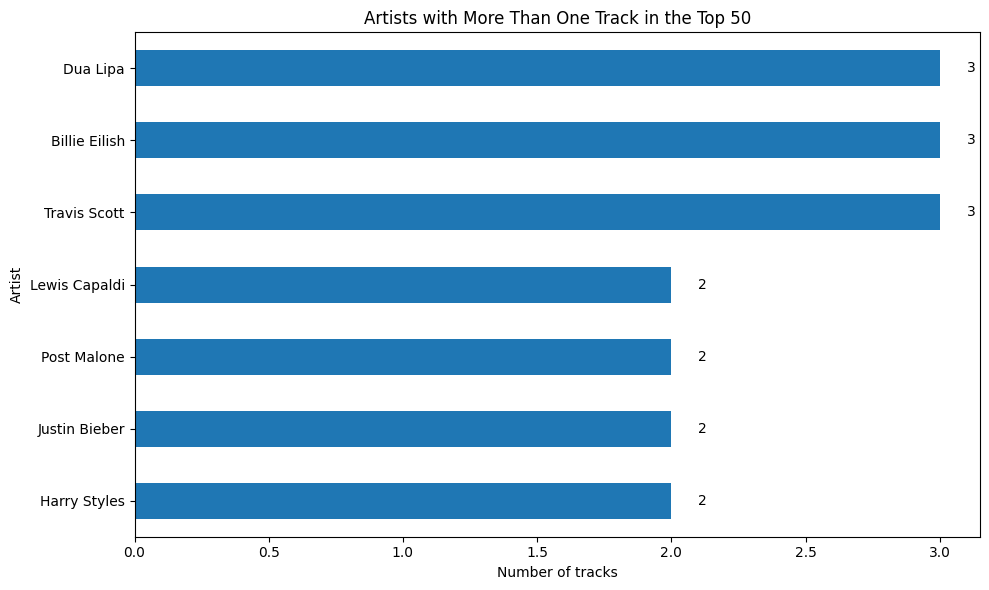

In [10]:
plt.figure(figsize=(10, 6))
ax = artist_counts_more_than_one.sort_values().plot(kind="barh")
plt.title("Artists with More Than One Track in the Top 50")
plt.xlabel("Number of tracks")
plt.ylabel("Artist")
plt.tight_layout()
# Add value labels
for i, value in enumerate(artist_counts_more_than_one.sort_values()):
    ax.text(value + 0.1, i, str(value), va="center")
plt.show()

##### Danceability distribution: 

Are the top tracks generally danceable?

Low danceability songs [0.0 - 0.5]:  3
Medium danceability songs [0.5 - 0.7]:  14
High danceability songs [0.7 - 1.0]:  33


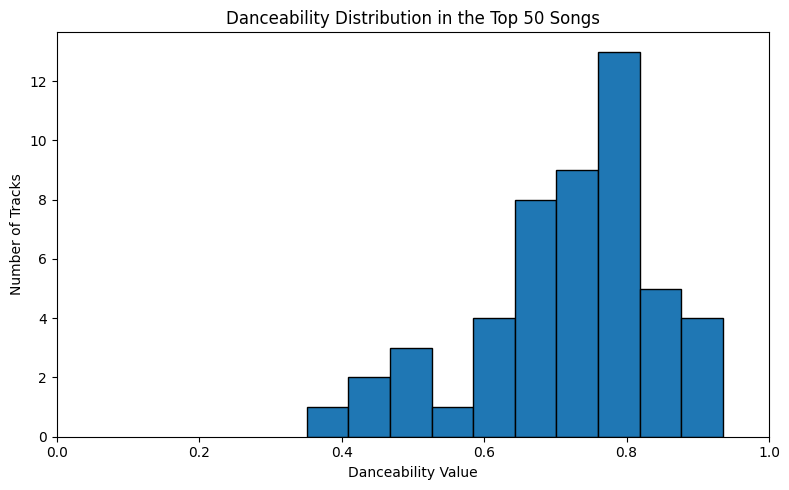

In [21]:
# Select danceability column
low_danceability = (df["danceability"] < 0.5).sum()
medium_danceability = ((df["danceability"] >= 0.5) & (df["danceability"] < 0.7)).sum()
high_danceability = (df["danceability"] >= 0.7).sum()

print("Low danceability songs [0.0 - 0.5]: ", low_danceability)
print("Medium danceability songs [0.5 - 0.7]: ", medium_danceability)
print("High danceability songs [0.7 - 1.0]: ", high_danceability)

# Create histogram
plt.figure(figsize=(8, 5))

plt.hist(df["danceability"], bins=10, edgecolor="black")

plt.title("Danceability Distribution in the Top 50 Songs")
plt.xlabel("Danceability Value")
plt.ylabel("Number of Tracks")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

The danceability distribution was analyzed using a histogram. Danceability values range from 0 to 1, where higher values indicate that a track is more suitable for dancing.The results show that the Top 50 tracks are generally danceable. The mean danceability value is 0.717, and the median value is 0.746, which means that the central tendency of the dataset is above 0.7. In addition, 33 out of 50 tracks have high danceability values between 0.7 and 1.0, while only 3 tracks have low danceability values below 0.5.
Most songs are concentrated between approximately 0.65 and 0.85, suggesting that danceability is relatively high across the dataset. However, the values range from 0.351 to 0.935, showing that there is still some variation among the tracks. Overall, the Top 50 songs in this dataset can be considered mostly danceable.


##### Energy distribution: 

Are the top tracks generally energetic?

Low energy songs [0.0 - 0.5]: 13
Medium energy songs [0.5 - 0.7]: 16
High energy songs [0.7 - 1.0]: 21


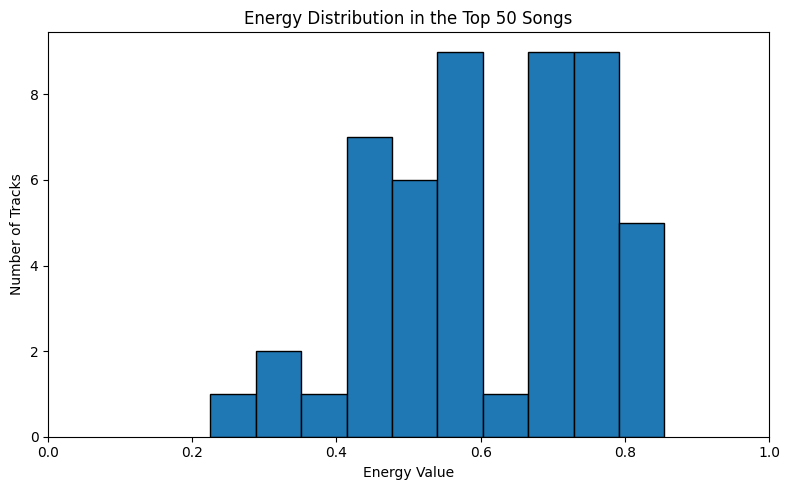

In [22]:
# Energy categories
low_energy = (df["energy"] < 0.5).sum()
medium_energy = ((df["energy"] >= 0.5) & (df["energy"] < 0.7)).sum()
high_energy = (df["energy"] >= 0.7).sum()

print("Low energy songs [0.0 - 0.5]:", low_energy)
print("Medium energy songs [0.5 - 0.7]:", medium_energy)
print("High energy songs [0.7 - 1.0]:", high_energy)

# Create histogram
plt.figure(figsize=(8, 5))

plt.hist( df["energy"], bins=10, edgecolor="black")

plt.title("Energy Distribution in the Top 50 Songs")
plt.xlabel("Energy Value")
plt.ylabel("Number of Tracks")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

The energy distribution shows that the Top 50 tracks are generally moderate to high in energy. The mean energy value is 0.609 and the median is 0.597, meaning the central tendency is around the medium-energy range. 
Out of 50 tracks, 13 songs have low energy values below 0.5, 16 songs have medium energy values between 0.5 and 0.7, and 21 songs have high energy values above 0.7. This means that most tracks, 37 out of 50, have energy values above 0.5. 
The values range from 0.225 to 0.855, showing that the dataset includes both calmer and more energetic songs. Overall, popular tracks in this dataset tend to be moderately energetic, with a noticeable number of highly energetic songs.

##### Tempo distribution: 

What is the common tempo range?

Common tempo range based on middle 50% of songs:
Q1: 99.55725
Q3: 132.317
Unusual tempo values:
Empty DataFrame
Columns: [track_name, artist, tempo]
Index: []


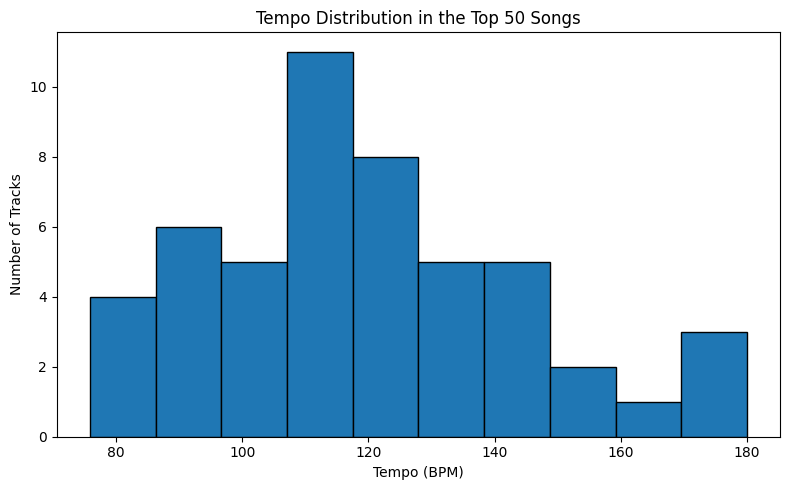

In [23]:
q1 = df["tempo"].quantile(0.25)
q3 = df["tempo"].quantile(0.75)

print("Common tempo range based on middle 50% of songs:")
print("Q1:", q1)
print("Q3:", q3)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

unusual_tempo = df[(df["tempo"] < lower_bound) | (df["tempo"] > upper_bound)]

print("Unusual tempo values:")
print(unusual_tempo[["track_name", "artist", "tempo"]])

# Create histogram
plt.figure(figsize=(8, 5))

plt.hist(df["tempo"], bins=10, edgecolor="black")

plt.title("Tempo Distribution in the Top 50 Songs")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.show()

The tempo distribution was analyzed using a histogram. Tempo is measured in beats per minute, BPM, and the values in this dataset range from 75.80 BPM to 180.07 BPM. The mean tempo is 119.69 BPM, while the median is 116.97 BPM, showing that the central tempo of the Top 50 tracks is around 117–120 BPM. Based on the middle 50% of the songs, the common tempo range is approximately 99.56 BPM to 132.32 BPM. The histogram also shows that many tracks are concentrated around the 100–130 BPM range, suggesting that most popular songs in this dataset have a moderate tempo. No unusual tempo values were detected using the IQR method. However, the dataset still includes some slower songs below 90 BPM and some faster songs above 160 BPM, showing that there is variation in tempo among the Top 50 tracks.

##### Loudness distribution: 

How loud are the top tracks?

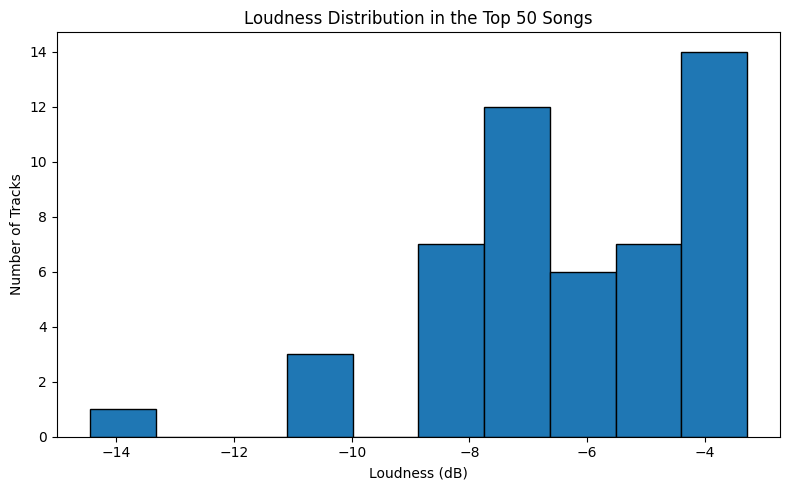

In [24]:
# Histogram
plt.figure(figsize=(8, 5))

plt.hist(df["loudness"], bins=10, edgecolor="black")

plt.title("Loudness Distribution in the Top 50 Songs")
plt.xlabel("Loudness (dB)")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.show()

The loudness distribution was analyzed to understand how loud the Top 50 tracks are. Loudness is measured in decibels, dB, and the values are usually negative. Values closer to 0 indicate louder tracks. In this dataset, loudness values range from -14.454 dB to -3.280 dB. The mean loudness is -6.226 dB, and the median is -5.992 dB. This shows that most tracks are relatively loud, which is expected for popular commercial music. The middle 50% of songs are between approximately -7.553 dB and -4.286 dB, suggesting that many tracks are concentrated in a loud, radio-friendly range. Overall, the Top 50 songs are generally loud and commercially mastered, although a few tracks are noticeably quieter than the rest.

##### Duration distribution: 

How long are popular songs?

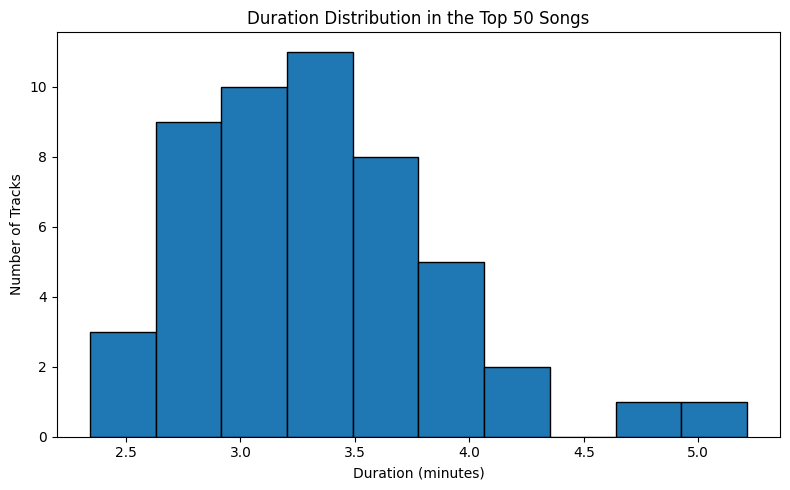

In [25]:
df["duration_min"] = df["duration_ms"] / 60000

# Histogram
plt.figure(figsize=(8, 5))

plt.hist(df["duration_min"], bins=10, edgecolor="black")

plt.title("Duration Distribution in the Top 50 Songs")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.show()

The duration distribution was analyzed to understand how long popular songs are. Since the original duration column was measured in milliseconds, it was converted into minutes for easier interpretation. The average song duration is approximately 3.33 minutes, while the median duration is 3.30 minutes. The shortest song is about 2.34 minutes, and the longest song is about 5.21 minutes. The middle 50% of songs are between approximately 2.93 and 3.58 minutes. This suggests that most popular songs in the Top 50 follow a common commercial duration, usually around 3 to 3.5 minutes. This length is typical for streaming and radio-friendly songs. However, the dataset also includes some shorter and longer tracks, showing that popular songs do not all follow exactly the same structure.

##### Average audio features: 

What is the general audio profile of popular tracks?

Average audio feature values:
instrumentalness    0.015962
speechiness         0.124158
liveness            0.196552
acousticness        0.256206
valence             0.555710
energy              0.609300
danceability        0.716720
dtype: float64


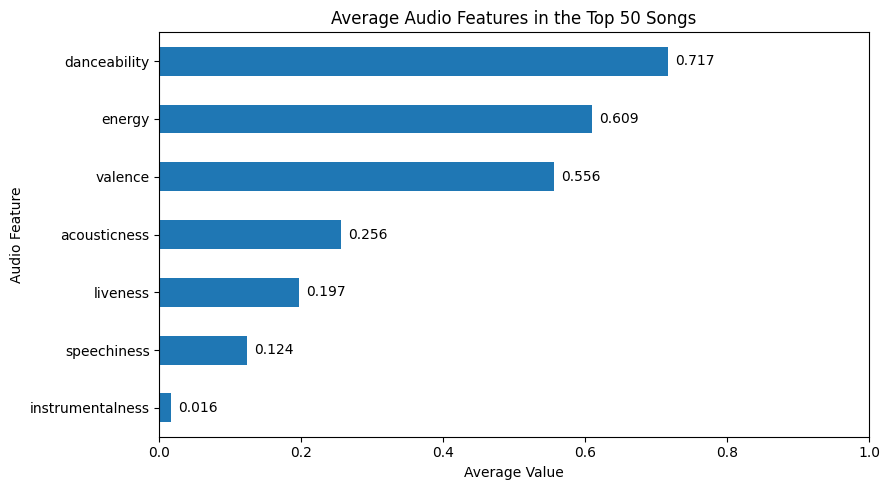

In [16]:
audio_features = [
    "danceability",
    "energy",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "valence"
]

average_features = df[audio_features].mean().sort_values()

print("Average audio feature values:")
print(average_features)

# Bar chart
plt.figure(figsize=(9, 5))

ax = average_features.plot(kind="barh")

plt.title("Average Audio Features in the Top 50 Songs")
plt.xlabel("Average Value")
plt.ylabel("Audio Feature")
plt.xlim(0, 1)

# Add value labels
for i, value in enumerate(average_features):
    ax.text(value + 0.01, i, round(value, 3), va="center")

plt.tight_layout()
plt.show()

The average audio features were analyzed to understand the general sound profile of the Top 50 tracks. The selected features were danceability, energy, acousticness, speechiness, instrumentalness, liveness, and valence. These features mostly range from 0 to 1. The highest average feature is danceability, with a mean value of 0.717. This suggests that the Top 50 tracks are generally suitable for dancing or rhythmic listening. Energy is also relatively high, with an average value of 0.609, showing that popular tracks tend to have a moderate to high level of intensity. Valence has an average value of 0.556, which suggests that the emotional tone of the songs is mixed but slightly positive. Acousticness has a lower average value of 0.256, indicating that most tracks are not strongly acoustic. Speechiness is also low, with an average value of 0.124, meaning that most tracks are not heavily speech-based. Instrumentalness is very low, with an average value of 0.016, which strongly suggests that the Top 50 songs are mostly vocal-based rather than instrumental. Overall, the general audio profile of the Top 50 songs is danceable, moderately energetic, mostly vocal-based, and more studio-produced than acoustic.

##### Correlation heatmap: 

Which audio features are related?

Correlation matrix:
                  danceability    energy  loudness  acousticness  speechiness  \
danceability          1.000000  0.152552  0.167147     -0.359135     0.226148   
energy                0.152552  1.000000  0.791640     -0.682479     0.074267   
loudness              0.167147  0.791640  1.000000     -0.498695    -0.021693   
acousticness         -0.359135 -0.682479 -0.498695      1.000000    -0.135392   
speechiness           0.226148  0.074267 -0.021693     -0.135392     1.000000   
instrumentalness     -0.017706 -0.385515 -0.553735      0.352184     0.028948   
liveness             -0.006648  0.069487 -0.069939     -0.128384    -0.142957   
valence               0.479953  0.393453  0.406772     -0.243192     0.053867   
tempo                 0.168956  0.075191  0.102097     -0.241119     0.215504   
duration_ms          -0.033763  0.081971  0.064130     -0.010988     0.366976   

                  instrumentalness  liveness   valence     tempo  duration_ms  
danceabi

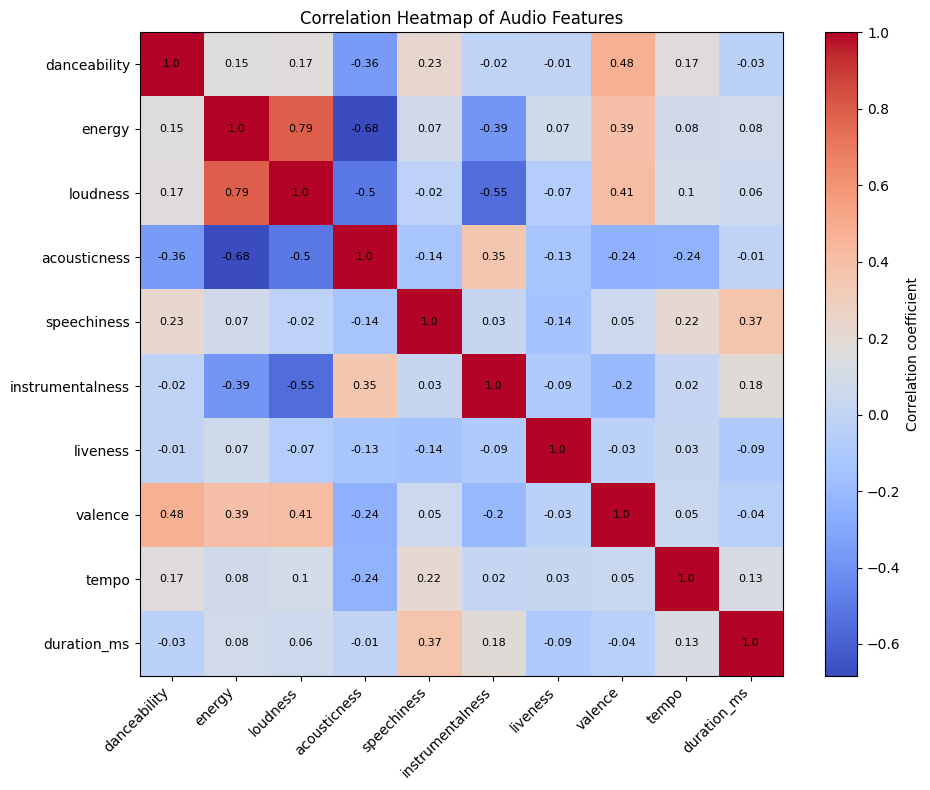

In [17]:
correlation_features = [
    "danceability",
    "energy",
    "loudness",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

corr_matrix = df[correlation_features].corr()

print("Correlation matrix:")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation coefficient")

plt.xticks(range(len(correlation_features)), correlation_features, rotation=45, ha="right")
plt.yticks(range(len(correlation_features)), correlation_features)

# Add correlation values inside cells
for i in range(len(correlation_features)):
    for j in range(len(correlation_features)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap of Audio Features")
plt.tight_layout()
plt.show()

Correlation close to +1  = strong positive relationship

Correlation close to -1  = strong negative relationship 

Correlation close to 0   = weak or no linear relationship 


The correlation heatmap was used to examine relationships between numerical audio features. Correlation values range from -1 to +1. A positive value means that two features tend to increase together, while a negative value means that one feature tends to decrease as the other increases. The strongest positive relationship is between energy and loudness, with a correlation of 0.79. This means that more energetic tracks also tend to be louder. This is reasonable because energetic songs are often produced with stronger intensity and higher volume. There is a strong negative relationship between energy and acousticness, with a correlation of -0.68. This suggests that more acoustic tracks tend to be less energetic, while more energetic tracks are usually less acoustic. Loudness also has a negative correlation with acousticness, around -0.50, meaning that more acoustic songs are generally quieter. Danceability has a moderate positive relationship with valence, around 0.48. This suggests that more danceable songs may also tend to sound more positive or cheerful. Valence also shows moderate positive relationships with energy and loudness, meaning that more energetic and louder tracks may also feel more positive. Most other correlations are weak, which means that many audio features are not strongly linearly related to each other in this dataset. Since the dataset contains only 50 songs, these correlations should be interpreted carefully as trends within this Top 50 list, not as general rules for all Spotify music.

##### Genre-based averages: 

How do audio features differ by genre?

In [18]:
audio_features = [
    "danceability",
    "energy",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "valence"
]

# Count songs per genre
genre_counts = df["genre"].value_counts()

# Keep only genres with more than one song
common_genres = genre_counts[genre_counts > 1].index

genre_avg = df[df["genre"].isin(common_genres)].groupby("genre")[audio_features].mean()

print("Average audio features by genre:")
genre_avg.round(3)

Average audio features by genre:


,danceability,energy,acousticness,speechiness,instrumentalness,liveness,valence
genre,,,,,,,
Alternative/Indie,0.662,0.551,0.584,0.060,0.000,0.122,0.502
Dance/Electronic,0.755,0.762,0.099,0.098,0.001,0.203,0.704
Electro-pop,0.790,0.475,0.256,0.216,0.065,0.086,0.628
Hip-Hop/Rap,0.766,0.583,0.189,0.155,0.000,0.280,0.499
Pop,0.678,0.587,0.324,0.113,0.047,0.214,0.563
R&B/Soul,0.651,0.702,0.129,0.109,0.000,0.090,0.560


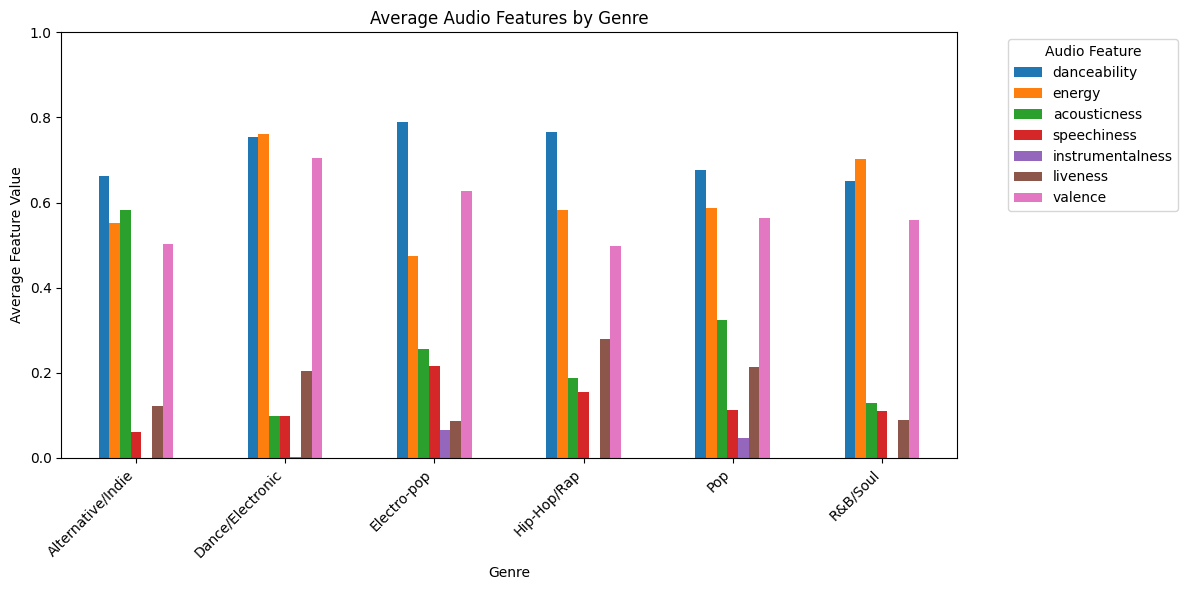

In [19]:
genre_avg.plot(kind="bar", figsize=(12, 6))

plt.title("Average Audio Features by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Feature Value")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Audio Feature", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

The genre-based averages were analyzed to understand how audio features differ across genres. Only genres with more than one track were considered, because genres represented by a single song are not reliable for comparison. Dance/Electronic has high average energy, danceability, and valence. This suggests that Dance/Electronic tracks in the dataset are generally rhythmic, energetic, and positive-sounding. Hip-Hop/Rap also has high average danceability and relatively higher speechiness compared with several other genres, which is expected because rap tracks often contain more spoken or rhythmic vocal delivery. Pop has moderate values across most features. It has relatively high danceability and moderate energy, which suggests that Pop tracks in the Top 50 are generally balanced and accessible. Alternative/Indie shows the highest acousticness among the common genres, suggesting that these tracks may rely more on acoustic or less heavily produced sounds. R&B/Soul has relatively high energy in this dataset, but because it has only two tracks, this result should be interpreted carefully. Overall, the genre-based analysis shows that different genres have different audio profiles. Dance/Electronic appears more energetic and positive, Hip-Hop/Rap appears danceable and more speech-oriented, while Alternative/Indie appears more acoustic. However, some genres have only a small number of songs, so the results should be considered as observations within this dataset rather than broad conclusions about the genres.

#### 6- Outlier Detection
Why IQR is suitable here

The dataset has only 50 songs, and many music features are not normally distributed. For example:

speechiness is usually very low for most songs, but can be high for rap-heavy tracks.
instrumentalness is usually near zero for vocal songs.
duration can have a few longer songs.
loudness can vary depending on mastering style.
tempo may have slower ballads and faster dance tracks.

The IQR method is useful because it is based on quartiles:

IQR = Q3 - Q1
lower limit = Q1 - 1.5 × IQR
upper limit = Q3 + 1.5 × IQR

The IQR method was used for outlier detection because it is robust and suitable for small datasets with non-normal distributions. Many Spotify audio features, such as speechiness, instrumentalness, acousticness, and duration, can be skewed, so mean-based methods such as Z-score may not be reliable. The IQR method allows unusual values to be identified based on the spread of the middle 50% of the data.

In this project, outliers are not automatically considered errors. Since music tracks can differ naturally by genre, production style, and artistic choice, detected outliers were interpreted as musically different tracks. For example, high speechiness may indicate a rap-heavy song, high acousticness may indicate an acoustic or ballad-like track, and long duration may indicate a song that differs from typical radio-friendly commercial length.

Because this project does not involve supervised classification, class imbalance was not analyzed. However, categorical imbalance was considered through genre and artist distributions, which showed that some genres and artists appear more frequently than others in the Top 50.

#### 7- Key Insights and Conclusion

This exploratory data analysis examined the Spotify Top 50 tracks from 2020 to identify patterns in genre, artist frequency, and audio features. The analysis shows that Pop and Hip-Hop/Rap are the most common genres in the dataset. Together, they represent more than half of the Top 50 tracks, suggesting that popular music in this list is strongly concentrated around these two genres. However, several other genres also appear, showing that the Top 50 includes some musical diversity. The artist analysis shows that a small number of artists appear more than once. Dua Lipa, Billie Eilish, and Travis Scott each have three tracks, while Lewis Capaldi, Post Malone, Justin Bieber, and Harry Styles each have two tracks. This means that some artists had multiple popular songs, but the dataset is not completely dominated by only a few artists. The audio feature analysis shows that the Top 50 tracks are generally danceable and moderately energetic. Danceability has a high average value, and most songs have danceability values above 0.7. Energy is also generally moderate to high, although there is more variation compared with danceability. Tempo values are mostly concentrated around 100 to 132 BPM, which suggests that popular songs commonly fall within a moderate tempo range.

The loudness analysis shows that most tracks are relatively loud, with an average loudness around -6.23 dB. This supports the idea that popular tracks are usually commercially mastered. The duration analysis shows that most songs are around 3 to 3.5 minutes long, which is consistent with common commercial song lengths. The average audio feature profile suggests that the Top 50 songs are mostly vocal-based, danceable, moderately energetic, and not strongly acoustic or instrumental. The very low instrumentalness value indicates that instrumental tracks are rare in this dataset. The correlation heatmap shows that energy and loudness have the strongest positive relationship, meaning that more energetic tracks tend to be louder. Energy and acousticness have a strong negative relationship, meaning that more acoustic songs tend to be less energetic. These relationships help explain some of the general sound characteristics of popular tracks.

Overall, the Spotify Top 50 tracks in this dataset are mainly characterized by high danceability, moderate to high energy, commercial loudness, vocal-based production, and common song durations. The results suggest that popular songs in 2020 tended to be accessible, rhythmic, and professionally produced. However, because the dataset contains only 50 tracks from one year, the findings should be interpreted as trends within this specific dataset rather than general conclusions about all Spotify music.


In [20]:
# 10- Conclusion